In [14]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np


In [15]:
continente_europa = pd.read_csv("continente_europa.csv")
continente_norteamerica = pd.read_csv("continente_norteamerica.csv")
continente_sudamerica = pd.read_csv("continente_sudamerica.csv")
continente_africa = pd.read_csv("continente_africa.csv")
continente_asia = pd.read_csv("continente_asia.csv")
continente_oceania = pd.read_csv("continente_oceania.csv")
world_generation = pd.read_csv("world_generation.csv")

    Test Set Metrics: AFRICA
    Best parameters:
    changepoint_prior_scale: 0.5
    seasonality_prior_scale: 0.1
    seasonality_mode: multiplicative
    
    MAE: 128.42
    RMSE: 16.87
    MAPE: 16.07%
    TRAIN: 0.7

    Best parameters: SUDAMERICA
    changepoint_prior_scale: 0.1
    seasonality_prior_scale: 0.01
    seasonality_mode: additive
    Best RMSE: 51.93
    
    Test Set Metrics:
    MAE: 100.08
    RMSE: 51.93
    MAPE: 8.66%
    TRAIN:0.6

    Best parameters: ASIA
    changepoint_prior_scale: 0.5
    seasonality_prior_scale: 0.1
    seasonality_mode: multiplicative
    Best RMSE: 435.43
    
    Test Set Metrics:
    MAE: 2409.33
    RMSE: 435.43
    MAPE: 18.83%
    TRAIN: 0.7

    Best parameters:OCEANIA
    changepoint_prior_scale: 0.5
    seasonality_prior_scale: 10.0
    seasonality_mode: additive
    Best RMSE: 16.80
    
    Test Set Metrics:
    MAE: 15.56
    RMSE: 16.80
    MAPE: 4.92%
    TRAIN: 0.7

    Best parameters:WORLD
    changepoint_prior_scale: 0.1
    seasonality_prior_scale: 1.0
    seasonality_mode: additive
    Best RMSE: 262.84
    
    Test Set Metrics:
    MAE: 2663.69
    RMSE: 262.84
    MAPE: 10.32%
    TRAIN: 0.7

    Best parameters:EUROPA
    train_size = 0.7
    changepoint_prior_scale: 0.5
    seasonality_prior_scale: 0.1
    seasonality_mode: additive
    
    Best parameters:NORTEAMERICA
    train_size = 0.7
    changepoint_prior_scale: 0.5
    seasonality_prior_scale: 0.1
    seasonality_mode: additive
    

In [27]:
import pandas as pd
import numpy as np
from prophet import Prophet
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error

def europa_norteamerica(dato, future_periods=5):
    """
    Predicts electricity generation using Facebook Prophet with optimized parameters.
    
    Parameters:
    dato (pd.DataFrame): DataFrame containing 'year' and 'electricity_generation' columns
    future_periods (int): Number of years to forecast into the future
    
    Returns:
    dict: Dictionary containing the model, forecast, metrics, and processed data
    """
    # Prepare data for Prophet
    prophet_data = dato.copy()
    prophet_data['ds'] = pd.to_datetime(prophet_data['year'], format='%Y')
    prophet_data['y'] = prophet_data['electricity_generation']
    
    # Split data into training (70%) and test (30%)
    train_size = int(len(prophet_data) * 0.7)
    train_data = prophet_data[:train_size]
    test_data = prophet_data[train_size:]
    print(test_data)
    
    # Create and fit model with optimized parameters
    model = Prophet(
        yearly_seasonality=True,
        changepoint_prior_scale=0.5,
        seasonality_prior_scale=0.1,
        seasonality_mode='additive'
    )
    model.fit(prophet_data)  # Fit on all data for final predictions
    
    # Generate predictions for test period (for metrics calculation)
    test_future = model.make_future_dataframe(periods=len(test_data), freq='Y')
    test_forecast = model.predict(test_future)
    test_predictions = test_forecast.iloc[-len(test_data):]
    
    # Calculate error metrics
    metrics = {
        'mae': mean_absolute_error(test_data['y'], test_predictions['yhat']),
        'rmse': np.sqrt(mean_squared_error(test_data['y'], test_predictions['yhat'])),
        'mape': np.mean(np.abs((test_data['y'] - test_predictions['yhat']) / test_data['y'])) * 100
    }
    
    # Print metrics
    print("\nMétricas del conjunto de prueba:")
    print(f"MAE: {metrics['mae']:.2f}")
    print(f"RMSE: {metrics['rmse']:.2f}")
    print(f"MAPE: {metrics['mape']:.2f}%")
    
    # Generate future predictions
    future = model.make_future_dataframe(periods=future_periods, freq='Y')
    forecast = model.predict(future)
    
    # Create visualization
    plt.figure(figsize=(10, 6))
    
    # Plot actual data
    plt.plot(prophet_data['ds'], prophet_data['y'], 'r-', label="Datos reales")
    
    # Plot prediction
    plt.plot(forecast['ds'], forecast['yhat'], 'b-', label="Predicción")
    
    # Plot confidence interval
    plt.fill_between(
        forecast['ds'], 
        forecast['yhat_lower'], 
        forecast['yhat_upper'],
        color='blue', 
        alpha=0.2, 
        label="Intervalo de confianza"
    )
    
    # Labels and title
    plt.xlabel("Año")
    plt.ylabel("Generación de electricidad")
    plt.title("Predicción de Generación de Electricidad con Prophet")
    plt.legend()
    plt.grid(True)
    
    plt.show()
    
    # Return useful information
    return {
        'model': model,
        'forecast': forecast,
        'metrics': metrics,
        'prophet_data': prophet_data,
        'test_predictions': test_predictions
    }

16:27:19 - cmdstanpy - INFO - Chain [1] start processing


    year  electricity_generation         ds          y
26  2011               1040.9800 2011-01-01  1040.9800
27  2012               1090.1100 2012-01-01  1090.1100
28  2013               1137.3800 2013-01-01  1137.3800
29  2014               1135.1100 2014-01-01  1135.1100
30  2015               1160.4400 2015-01-01  1160.4400
31  2016               1162.2900 2016-01-01  1162.2900
32  2017               1159.5901 2017-01-01  1159.5901
33  2018               1174.5500 2018-01-01  1174.5500
34  2019               1183.3600 2019-01-01  1183.3600
35  2020               1167.2999 2020-01-01  1167.2999
36  2021               1218.2700 2021-01-01  1218.2700
37  2022               1245.3300 2022-01-01  1245.3300


16:27:19 - cmdstanpy - INFO - Chain [1] done processing
/home/nicolas/.pyenv/versions/3.10.6/envs/energy_production/lib/python3.10/site-packages/prophet/forecaster.py:1854: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  dates = pd.date_range(
/home/nicolas/.pyenv/versions/3.10.6/envs/energy_production/lib/python3.10/site-packages/prophet/forecaster.py:1854: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  dates = pd.date_range(



Métricas del conjunto de prueba:
MAE: 131.54
RMSE: 133.67
MAPE: nan%


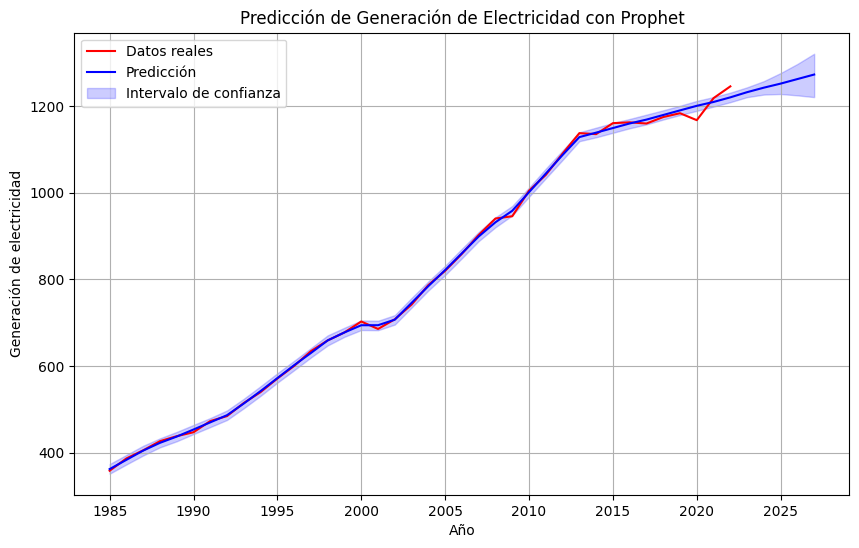

In [32]:
datos=europa_norteamerica(continente_sudamerica)

In [20]:
continente_norteamerica

,year,electricity_generation
0,1986,6487.563
1,1987,6748.470
2,1988,7064.200
3,1989,7537.124
4,1990,7640.277
5,1991,7786.258
6,1992,7842.673
7,1993,8110.909
8,1994,8287.688
9,1995,8520.539
